In [4]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

In [5]:
data=load_iris()

In [12]:
X=data.data
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train,y_train)
y_pred=dt_model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f'Accuracy of Decision Tree Classifier:{accuracy:.2f}')

Accuracy of Decision Tree Classifier:1.00


In [8]:
print("\nEnter the flower measurements:")
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))
newrow = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
prediction = dt_model.predict(newrow)
species = data.target_names[prediction[0]]
print(f"\nPredicted Iris species: {species}")


Enter the flower measurements:


Sepal length (cm):  2.8
Sepal width (cm):  4.1
Petal length (cm):  1.2
Petal width (cm):  5.8



Predicted Iris species: virginica


In [9]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:",cm)

Confusion Matrix: [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


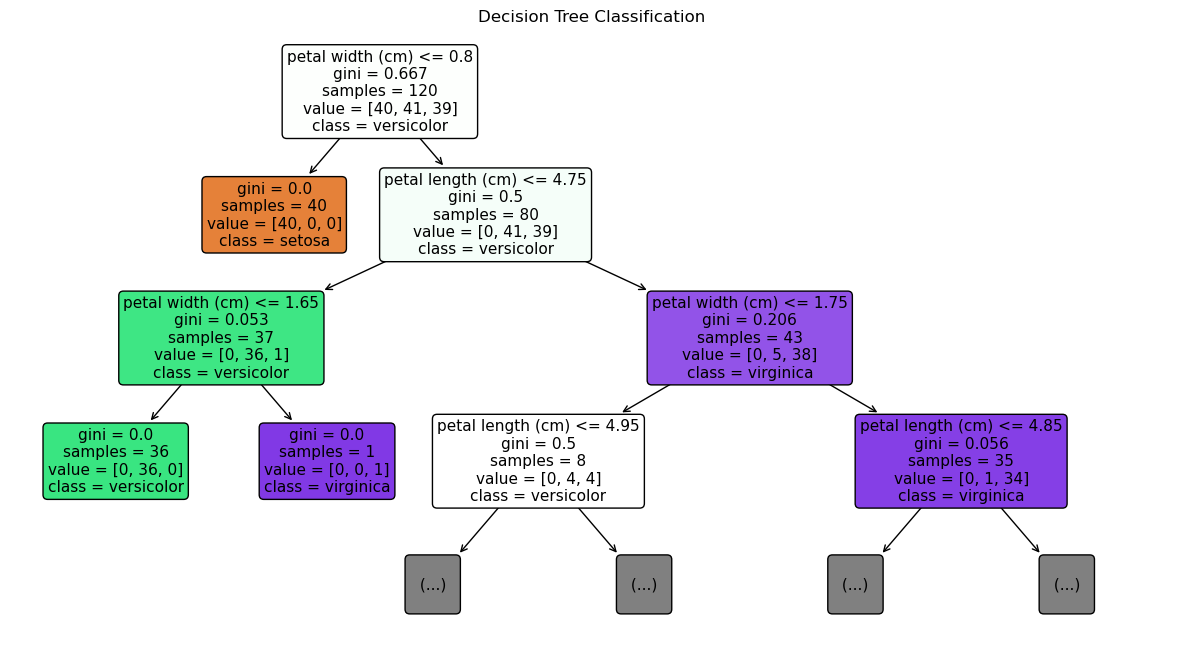

In [10]:
#Graph 3 - Decision Tree

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))

plot_tree(
    dt_model,
    feature_names=list(data.feature_names),
    class_names=list(data.target_names),
    max_depth=3,
    filled=True,
    rounded=True
)

plt.title("Decision Tree Classification")
plt.show()


    day temperature humidity    wind play
0    D1         Hot     High    Weak   No
1    D2         Hot     High  Strong   No
2    D3        Mild     High    Weak  Yes
3    D4        Cool     High    Weak  Yes
4    D5        Cool   Normal    Weak  Yes
5    D6        Cool   Normal  Strong   No
6    D7        Mild   Normal  Strong  Yes
7    D8         Hot     High    Weak   No
8    D9         Hot   Normal    Weak  Yes
9   D10        Cool   Normal    Weak  Yes
10  D11        Mild   Normal    Weak  Yes
11  D12        Mild     High  Strong   No
12  D13         Hot   Normal  Strong  Yes
13  D14        Mild     High    Weak  Yes
 
 Accuracy of Decision Tree Classifier: 0.67


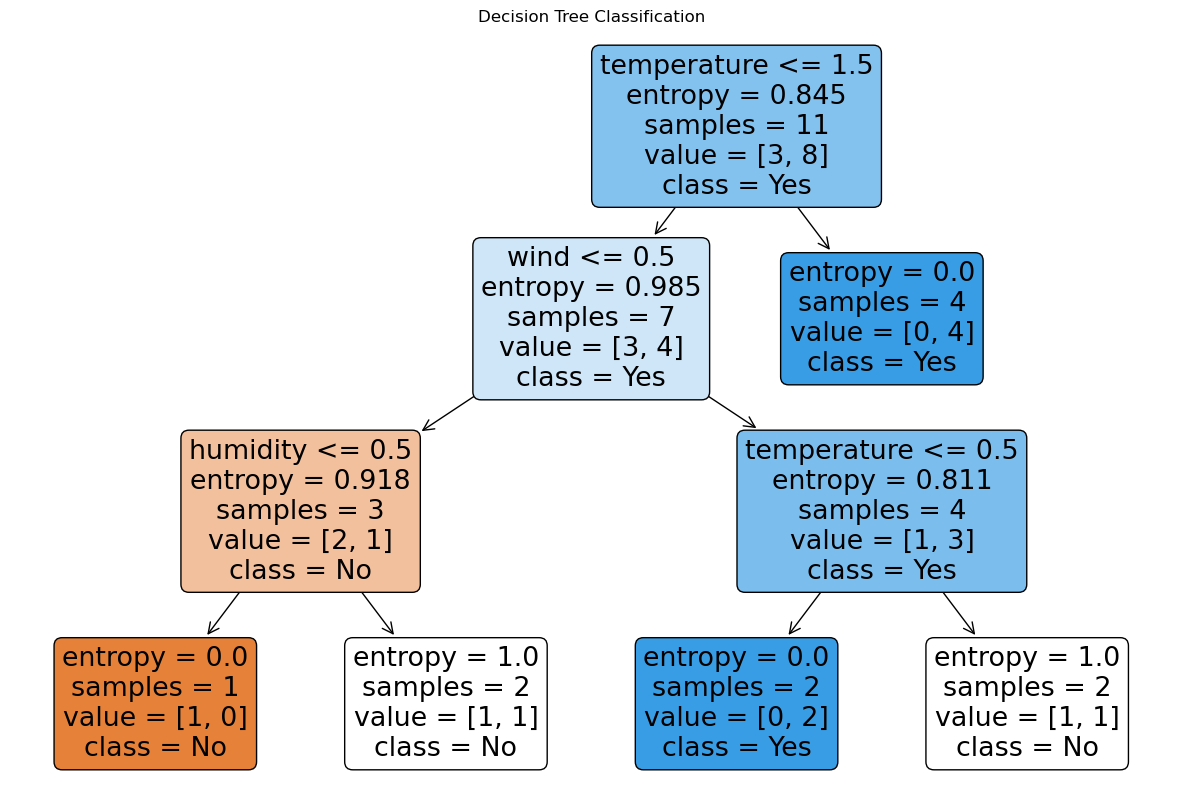

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load your dataset
df=pd.read_csv('/home/ksb/shahma DS/weather.csv')

print(df)

le_temperature = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()
le_play = LabelEncoder()

df["temperature"] = le_temperature.fit_transform(df["temperature"])
df["humidity"] = le_humidity.fit_transform(df["humidity"])
df["wind"] = le_wind.fit_transform(df["wind"])
df["play"] = le_play.fit_transform(df["play"])

X = df[["temperature", "humidity", "wind"]]
y = df["play"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f" \n Accuracy of Decision Tree Classifier: {accuracy:.2f}")
plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=["temperature", "humidity", "wind"],
    class_names=list(le_play.classes_),
    filled=True,
    rounded=True
)
plt.title("Decision Tree Classification")
plt.show()
